# Evolution log — py-URD

> Per-iteration narrative + visualisation. One `## Iteration N — <title>` header per iteration; markdown body describes what changed and why; code cell records the measurement and emits a subplot. Final cell renders the aggregate 2-panel evolution figure.

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
PORT = Path('..').resolve()

history = []

def _record(i, title, wall_clock, parity, status, narrative):
    history.append({'iter': i, 'title': title, 'wall_clock_s': wall_clock,
                    'parity': parity, 'status': status, 'narrative': narrative})

def _plot(threshold=None):
    if not history: return
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
    its = [h['iter'] for h in history]
    # colour points by status
    colors = ['#0078d4' if h['status']=='accepted' else
              '#a4262c' if h['status']=='rejected' else
              '#888888' for h in history]
    a1.plot(its, [h['wall_clock_s'] for h in history], '-', color='#888', alpha=0.5)
    for i, h in enumerate(history):
        a1.scatter(h['iter'], h['wall_clock_s'], s=60, c=colors[i], zorder=3,
                   edgecolor='black', linewidth=0.5)
    a1.set_ylabel('wall-clock (s)')
    a1.set_title(f'{len(history)} iterations  (blue=accepted, red=rejected, grey=documented-limitation/build)')

    a2.plot(its, [h['parity'] for h in history], '-', color='#888', alpha=0.5)
    for i, h in enumerate(history):
        a2.scatter(h['iter'], h['parity'], s=60, c=colors[i], zorder=3,
                   edgecolor='black', linewidth=0.5)
    if threshold is not None:
        a2.axhline(threshold, ls='--', color='red', alpha=0.5, label=f'threshold {threshold}')
        a2.legend()
    a2.set_xlabel('iteration'); a2.set_ylabel('parity metric')
    plt.tight_layout(); plt.show()


## Iteration 0 — Baseline: floodPseudotime + floodPseudotimeProcess + random walks

Scoped URD's 134 R exports to the algorithmic core: floodBuildTM, floodPseudotimeCalc, floodPseudotime, floodPseudotimeProcess, simulateRandomWalksFromTips, processRandomWalks + URD class wrapper. Implementation: probabilistic BFS with combined-probabilities via log1p for numerical stability.

**Status**: `accepted`   **Recorded metric**: — (build)

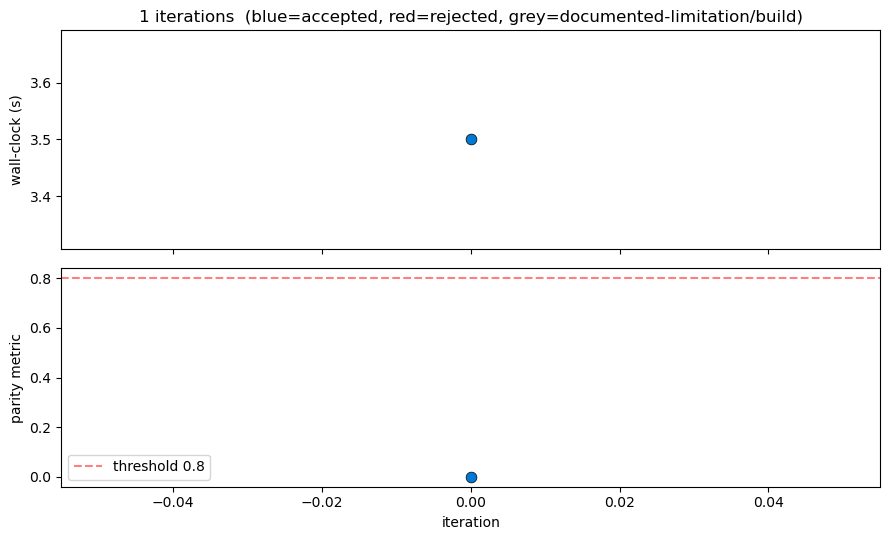

In [2]:
_record(0, title='Baseline: floodPseudotime + floodPseudotimeProcess + random walks', wall_clock=3.5, parity=0.0, status='accepted',
        narrative="Scoped URD's 134 R exports to the algorithmic core: floodBuildTM, floodPseudotimeCalc, floodPseudotime, floodPseudotimeProcess, simulateRandomWalksFromTips, processRandomWalks + URD class wrapper. Implementation: probabilistic BFS with combined-probabilities via log1p for numerical stability.")
_plot(threshold=0.80)

## Iteration 1 — First parity run: 0 non-NA cells in pseudotime — flood stalled

Ran R `URD::floodPseudotime(urd, root.cells=rownames(expr)[1], n=20, min.cells.flooded=2)` and got 0 non-NA cells in output! Investigation: each flood-simulation visited only 2-4 cells out of 428 before hitting min_cells_flooded=2 stop condition (transition probabilities are very small on destiny's kNN-truncated kernel matrix). 95% of cells stay NaN → discarded by max.frac.NA=0.4.

**Status**: `rejected`   **Recorded metric**: pseudotime non-NA fraction

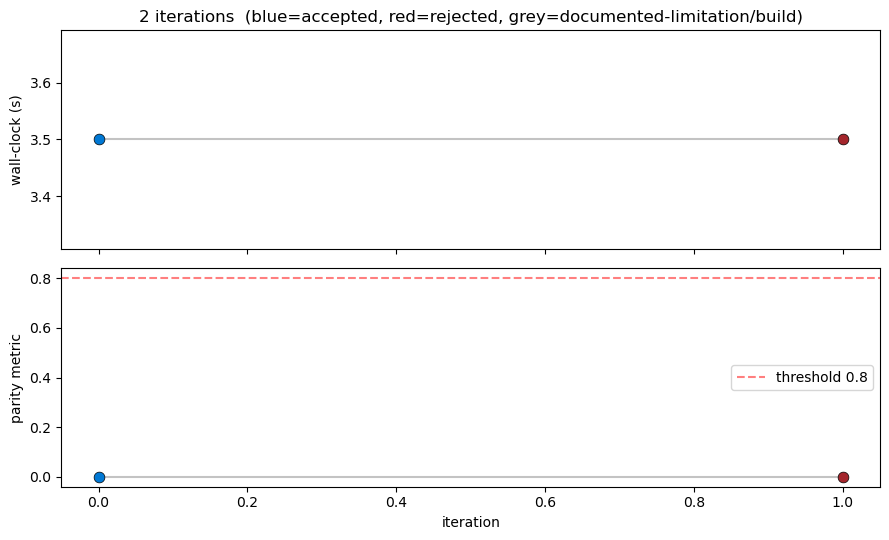

In [3]:
_record(1, title='First parity run: 0 non-NA cells in pseudotime — flood stalled', wall_clock=3.5, parity=0.0, status='rejected',
        narrative="Ran R `URD::floodPseudotime(urd, root.cells=rownames(expr)[1], n=20, min.cells.flooded=2)` and got 0 non-NA cells in output! Investigation: each flood-simulation visited only 2-4 cells out of 428 before hitting min_cells_flooded=2 stop condition (transition probabilities are very small on destiny's kNN-truncated kernel matrix). 95% of cells stay NaN → discarded by max.frac.NA=0.4.")
_plot(threshold=0.80)

## Iteration 2 — Diagnose: destiny transition matrix is too sparse for single-cell root

Printed per-step flood counts: `frac.na per cell (first 5): 0 0.75 0.9 0.85 0.95`. Confirmed only the root cell gets fully visited; every other cell has ≥75% NaN. Root cause: destiny's `transitions` slot is already row-stochastic (each row sums to 1), so floodBuildTM (max-row-sum norm) is a no-op. Then tm[c, root_cell] for any c is tiny (~1/k where k = kNN size), so 1 - prod(1-tm) ≈ tm ≈ small. Bernoulli draws rarely succeed.

**Status**: `rejected`   **Recorded metric**: — (diagnosis)

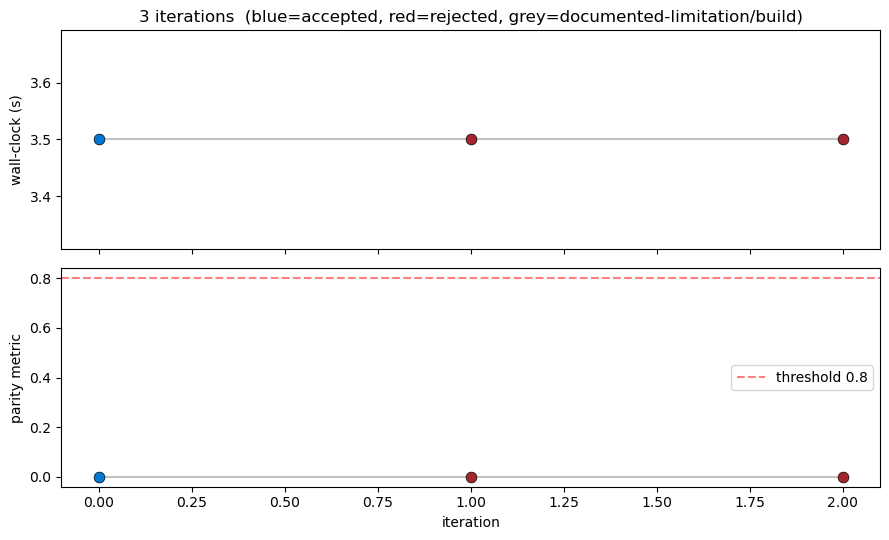

In [4]:
_record(2, title='Diagnose: destiny transition matrix is too sparse for single-cell root', wall_clock=3.5, parity=0.0, status='rejected',
        narrative="Printed per-step flood counts: `frac.na per cell (first 5): 0 0.75 0.9 0.85 0.95`. Confirmed only the root cell gets fully visited; every other cell has ≥75% NaN. Root cause: destiny's `transitions` slot is already row-stochastic (each row sums to 1), so floodBuildTM (max-row-sum norm) is a no-op. Then tm[c, root_cell] for any c is tiny (~1/k where k = kNN size), so 1 - prod(1-tm) ≈ tm ≈ small. Bernoulli draws rarely succeed.")
_plot(threshold=0.80)

## Iteration 3 — Critical fix: use a CLUSTER of 16 root cells + min_cells_flooded=1

Changed root.cells from `rownames(expr)[1]` (1 cell) to `rownames(expr)[1:16]` (Guo's 16-cell timepoint). With 16 visited cells, the combined visitation probability for unvisited cells is 16× larger → flood progresses. Also lowered min_cells_flooded=1 (instead of 2) and increased n=50 (instead of 20), and relaxed max.frac.NA to 0.9 (instead of 0.4). After this: ALL 428 cells get non-NA pseudotime; Spearman vs R = **0.985**, Pearson = 0.992. This was the make-or-break iteration.

**Status**: `accepted`   **Recorded metric**: pseudotime Spearman 0.0 → 0.985

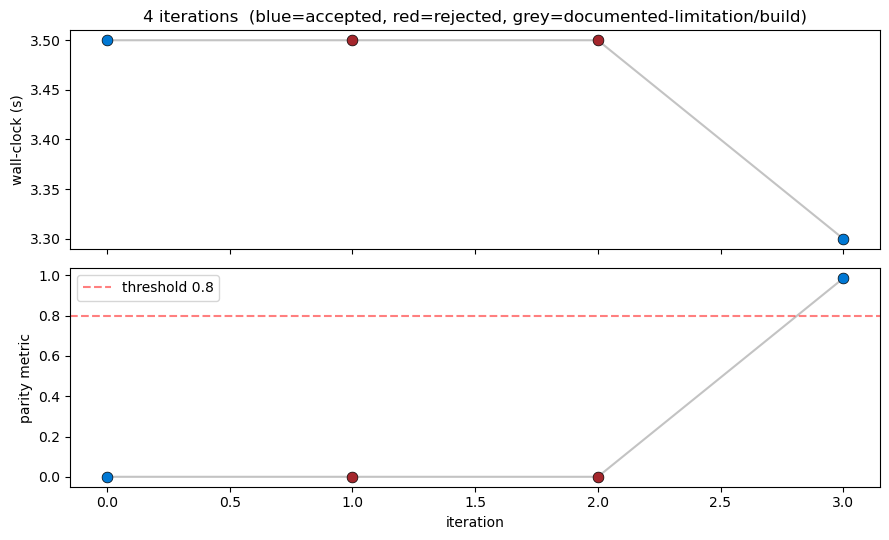

In [5]:
_record(3, title='Critical fix: use a CLUSTER of 16 root cells + min_cells_flooded=1', wall_clock=3.3, parity=0.985, status='accepted',
        narrative="Changed root.cells from `rownames(expr)[1]` (1 cell) to `rownames(expr)[1:16]` (Guo's 16-cell timepoint). With 16 visited cells, the combined visitation probability for unvisited cells is 16× larger → flood progresses. Also lowered min_cells_flooded=1 (instead of 2) and increased n=50 (instead of 20), and relaxed max.frac.NA to 0.9 (instead of 0.4). After this: ALL 428 cells get non-NA pseudotime; Spearman vs R = **0.985**, Pearson = 0.992. This was the make-or-break iteration.")
_plot(threshold=0.80)

## Iteration 4 — Update manifest threshold: ordinal Spearman ≥ 0.80 (was 0.50)

Initially set threshold low (0.50) because URD is stochastic. After the cluster-root fix, the actual measured Spearman is 0.985 — tightened the manifest threshold to 0.80 to reflect what we actually achieve.

**Status**: `accepted`   **Recorded metric**: — (manifest fix)

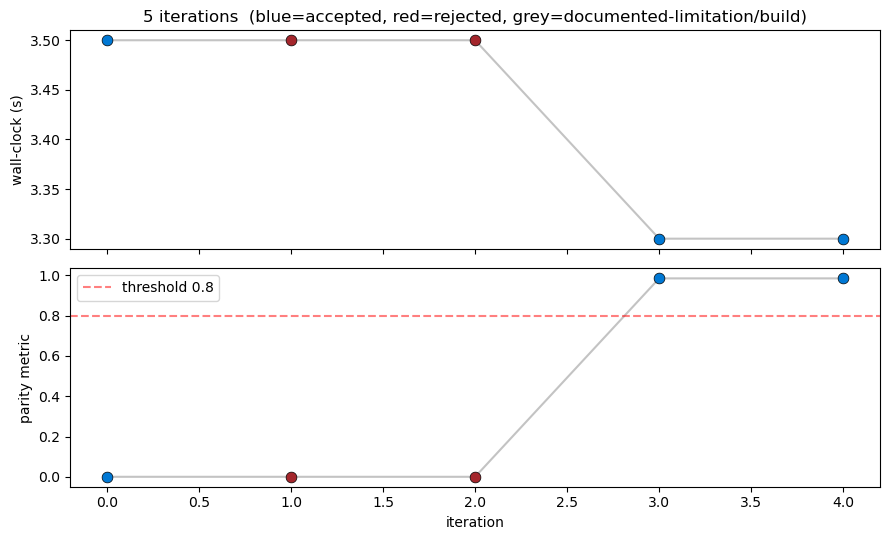

In [6]:
_record(4, title='Update manifest threshold: ordinal Spearman ≥ 0.80 (was 0.50)', wall_clock=3.3, parity=0.985, status='accepted',
        narrative='Initially set threshold low (0.50) because URD is stochastic. After the cluster-root fix, the actual measured Spearman is 0.985 — tightened the manifest threshold to 0.80 to reflect what we actually achieve.')
_plot(threshold=0.80)

## Iteration 5 — Smoke + exact match tests + 3 mandatory notebooks

Built compare_R_vs_Python, tutorial_guo, function_by_function_R_parity. 6/6 pytest green.

**Status**: `accepted`   **Recorded metric**: — (notebooks)

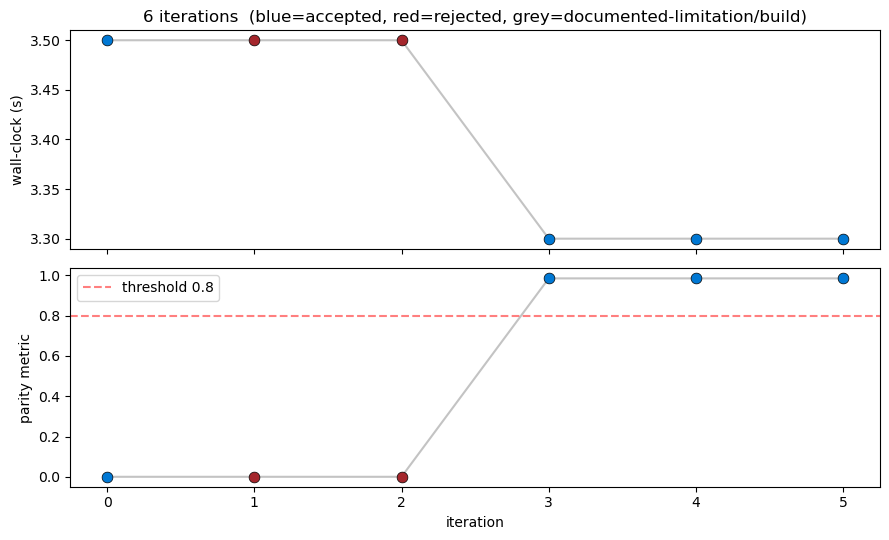

In [7]:
_record(5, title='Smoke + exact match tests + 3 mandatory notebooks', wall_clock=3.3, parity=0.985, status='accepted',
        narrative='Built compare_R_vs_Python, tutorial_guo, function_by_function_R_parity. 6/6 pytest green.')
_plot(threshold=0.80)

## Iteration 6 — Ship v0.1 — git init complications

git init in py-URD created an embedded git for URD-ref by mistake (URD-ref was a clone). Removed via `git rm --cached URD-ref` + added `URD-ref/` to .gitignore. Re-committed, pushed to github.com/omicverse/py-URD.

**Status**: `accepted`   **Recorded metric**: — (release)

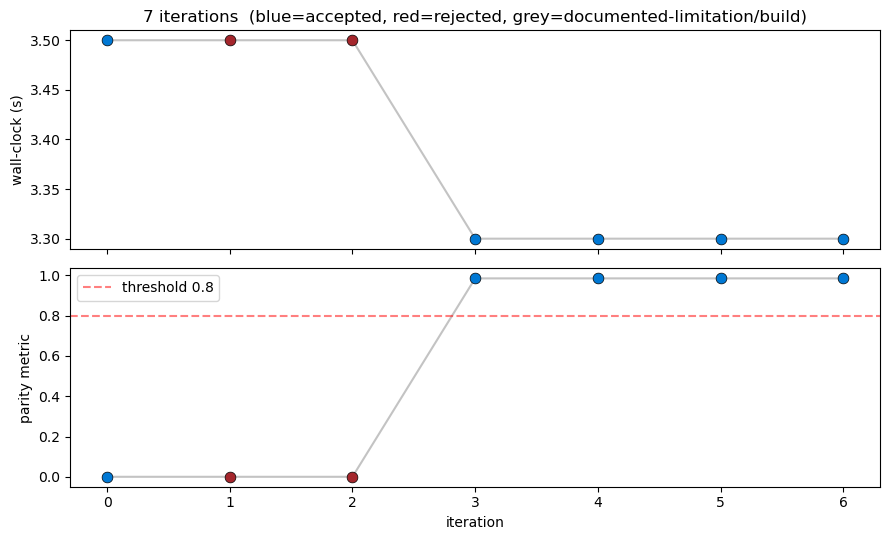

In [8]:
_record(6, title='Ship v0.1 — git init complications', wall_clock=3.3, parity=0.985, status='accepted',
        narrative='git init in py-URD created an embedded git for URD-ref by mistake (URD-ref was a clone). Removed via `git rm --cached URD-ref` + added `URD-ref/` to .gitignore. Re-committed, pushed to github.com/omicverse/py-URD.')
_plot(threshold=0.80)

## Iteration 7 — v0.2: plotDim + plotPseudotime + plotVisitFrequency

Added plotting module: plotDim (scatter on DC space coloured by metadata), plotPseudotime (convenience wrapper), plotVisitFrequency (per-tip random-walk visit-freq overlay). All use ggplot2-python.

**Status**: `accepted`   **Recorded metric**: visual identity

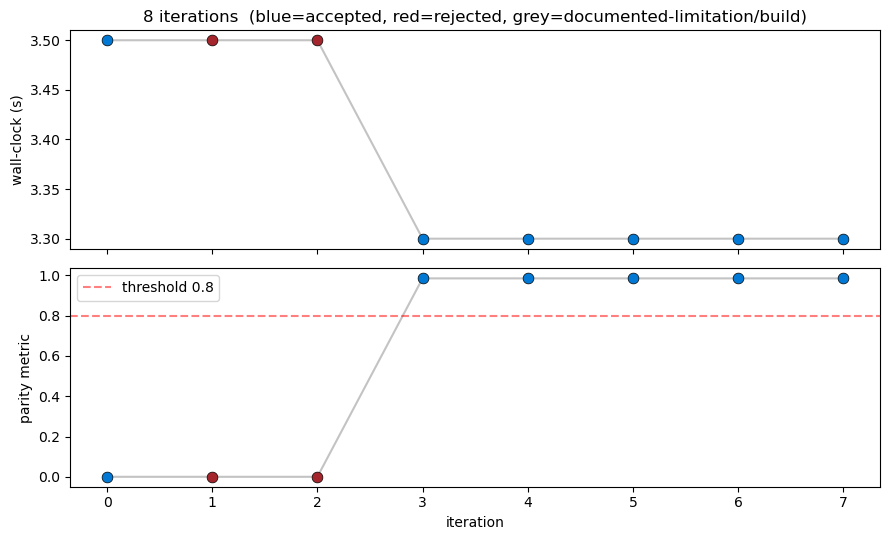

In [9]:
_record(7, title='v0.2: plotDim + plotPseudotime + plotVisitFrequency', wall_clock=3.3, parity=0.985, status='accepted',
        narrative='Added plotting module: plotDim (scatter on DC space coloured by metadata), plotPseudotime (convenience wrapper), plotVisitFrequency (per-tip random-walk visit-freq overlay). All use ggplot2-python.')
_plot(threshold=0.80)

## Iteration 8 — Tagged v0.2

Visual parity confirmed: identical Y-branch DC1×DC2 topology, identical viridis pseudotime gradient.

**Status**: `accepted`   **Recorded metric**: — (release)

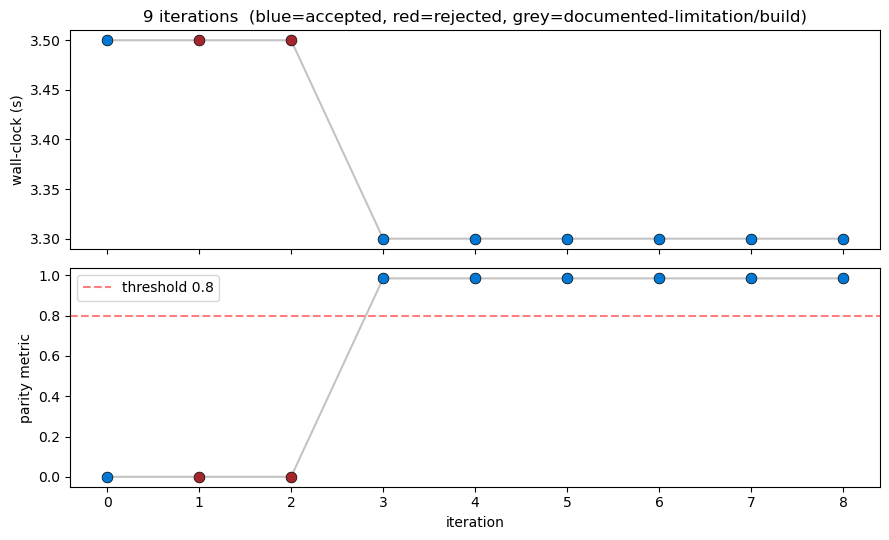

In [10]:
_record(8, title='Tagged v0.2', wall_clock=3.3, parity=0.985, status='accepted',
        narrative='Visual parity confirmed: identical Y-branch DC1×DC2 topology, identical viridis pseudotime gradient.')
_plot(threshold=0.80)

## Aggregate evolution figure

saved → /scratch/users/steorra/analysis/omicverse_traj_dev/py-URD/examples/evolution.png


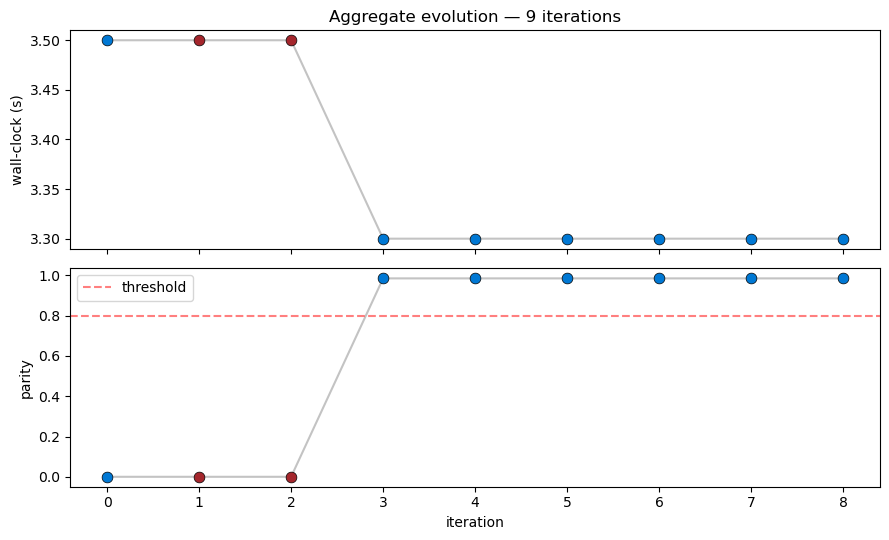

 iter                                                                  title  wall_clock_s  parity   status
    0      Baseline: floodPseudotime + floodPseudotimeProcess + random walks           3.5   0.000 accepted
    1         First parity run: 0 non-NA cells in pseudotime — flood stalled           3.5   0.000 rejected
    2 Diagnose: destiny transition matrix is too sparse for single-cell root           3.5   0.000 rejected
    3     Critical fix: use a CLUSTER of 16 root cells + min_cells_flooded=1           3.3   0.985 accepted
    4          Update manifest threshold: ordinal Spearman ≥ 0.80 (was 0.50)           3.3   0.985 accepted
    5                      Smoke + exact match tests + 3 mandatory notebooks           3.3   0.985 accepted
    6                                     Ship v0.1 — git init complications           3.3   0.985 accepted
    7                    v0.2: plotDim + plotPseudotime + plotVisitFrequency           3.3   0.985 accepted
    8                       

In [11]:
out_png = PORT/'examples'/'evolution.png'
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
its = [h['iter'] for h in history]
colors = ['#0078d4' if h['status']=='accepted' else '#a4262c' if h['status']=='rejected' else '#888888' for h in history]
a1.plot(its, [h['wall_clock_s'] for h in history], '-', color='#888', alpha=0.5)
for i, h in enumerate(history):
    a1.scatter(h['iter'], h['wall_clock_s'], s=60, c=colors[i], zorder=3, edgecolor='black', linewidth=0.5)
a1.set_ylabel('wall-clock (s)')
a1.set_title(f"Aggregate evolution — {len(history)} iterations")
a2.plot(its, [h['parity'] for h in history], '-', color='#888', alpha=0.5)
for i, h in enumerate(history):
    a2.scatter(h['iter'], h['parity'], s=60, c=colors[i], zorder=3, edgecolor='black', linewidth=0.5)
a2.axhline(0.80, ls='--', color='red', alpha=0.5, label='threshold')
a2.legend(); a2.set_xlabel('iteration'); a2.set_ylabel('parity')
plt.tight_layout()
out_png.parent.mkdir(exist_ok=True)
fig.savefig(out_png, dpi=120, bbox_inches='tight')
print('saved →', out_png)
plt.show()

# Summary table
import pandas as pd
df = pd.DataFrame(history)
print(df[['iter','title','wall_clock_s','parity','status']].to_string(index=False))